<a href="https://colab.research.google.com/github/Nazarchona/Tutorial/blob/main/%D0%9B%D0%A03_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D0%93%D1%83%D1%94%D0%B2_%D0%9D%D0%B0%D0%B7%D0%B0%D1%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 3. Машинне навчання
## Регресія: прогнозування вартості нерухомості

**Мета роботи:** виконати первинний аналіз даних, побудувати кілька моделей регресії, оцінити їхню якість та виконати підбір гіперпараметрів для моделі Random Forest.

### Датасет
Можна використати один із двох способів завантаження даних:

1. Завантажити файл з Google Drive:
https://drive.google.com/file/d/1u_-3X05st6uvrgQB1qNLyE8a7QjTJjvd/view?usp=sharing

2. Завантажити датасет з Kaggle:
https://www.kaggle.com/datasets/prokshitha/home-value-insights

> Посилання та вміст датасету на зовнішніх платформах можуть змінюватися.

## 1. Імпорт бібліотек
Імпортуйте бібліотеки, необхідні для роботи з даними, візуалізації та числових обчислень.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')





## 2. Завантаження даних
Завантажте файл двома способами.

### Варіант 1. Завантаження файлу з комп’ютера
Завантажте CSV-файл у середовище Colab.

In [2]:
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df.head()





Saving house_price_regression_dataset.csv to house_price_regression_dataset.csv


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


### Варіант 2. Завантаження датасету з Kaggle
Завантажте датасет безпосередньо з Kaggle та прочитайте CSV-файл у DataFrame `df`.

In [ ]:
# Ваш код:
# Завантажте датасет з Kaggle та створіть DataFrame `df`.





## 3. Опис ознак датасету

- **Square_Footage** — загальна житлова площа будинку.
- **Num_Bedrooms** — кількість спалень.
- **Num_Bathrooms** — кількість ванних кімнат.
- **Year_Built** — рік побудови будинку.
- **Lot_Size** — розмір земельної ділянки.
- **Garage_Size** — розмір гаража або кількість паркомісць.
- **Neighborhood_Quality** — оцінка якості району.
- **House_Price** — ціна будинку, цільова змінна.

## 4. Первинний аналіз даних

### Завдання 1. Перегляд даних
Виведіть перші рядки датасету та перегляньте його структуру.

In [3]:
print("Перші 5 рядків датасету:")
display(df.head())

print("\nЗагальна інформація про DataFrame:")
df.info()

print("\nРозмір датасету:")
print(df.shape)




Перші 5 рядків датасету:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06



Загальна інформація про DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB

Розмір датасету:
(1000, 8)


### Завдання 2. Перевірка дублікатів
Визначте кількість дубльованих рядків.

In [4]:
duplicates = df.duplicated().sum()

print("Кількість дублікатів:", duplicates)





Кількість дублікатів: 0


### Завдання 3. Перевірка пропущених значень
Визначте кількість пропущених значень у кожному стовпці.

In [5]:
missing_values = df.isnull().sum()

print("Кількість пропущених значень:")
print(missing_values)





Кількість пропущених значень:
Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64


### Завдання 4. Описова статистика
Виведіть основні статистичні характеристики числових ознак.

In [6]:
statistics = df.describe()

display(statistics)





,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


## 5. Аналіз окремих ознак

### Завдання 5. Ознака `Neighborhood_Quality`
Виведіть частоти значень ознаки `Neighborhood_Quality`.

In [7]:
neighborhood_counts = df["Neighborhood_Quality"].value_counts().sort_index()

print("Частоти Neighborhood_Quality:")
print(neighborhood_counts)

Частоти Neighborhood_Quality:
Neighborhood_Quality
1      91
2     105
3      85
4      99
5     109
6     101
7     102
8      97
9      88
10    123
Name: count, dtype: int64


### Завдання 6. Візуалізація `Neighborhood_Quality`
Побудуйте діаграму розподілу значень цієї ознаки.

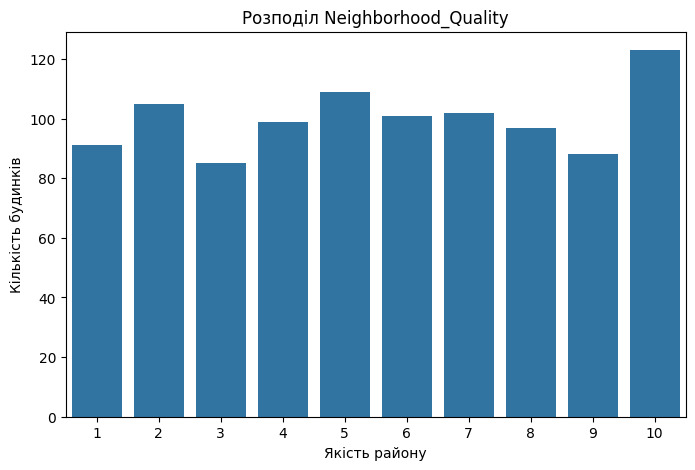

In [8]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Neighborhood_Quality"
)

plt.title("Розподіл Neighborhood_Quality")
plt.xlabel("Якість району")
plt.ylabel("Кількість будинків")

plt.show()





### Завдання 7. Ознака `Num_Bathrooms`
Виведіть частоти значень кількості ванних кімнат.

In [9]:
bathroom_counts = df["Num_Bathrooms"].value_counts().sort_index()

print("Частоти Num_Bathrooms:")
print(bathroom_counts)





Частоти Num_Bathrooms:
Num_Bathrooms
1    350
2    327
3    323
Name: count, dtype: int64


### Завдання 8. Візуалізація `Num_Bathrooms`
Побудуйте діаграму розподілу кількості ванних кімнат.

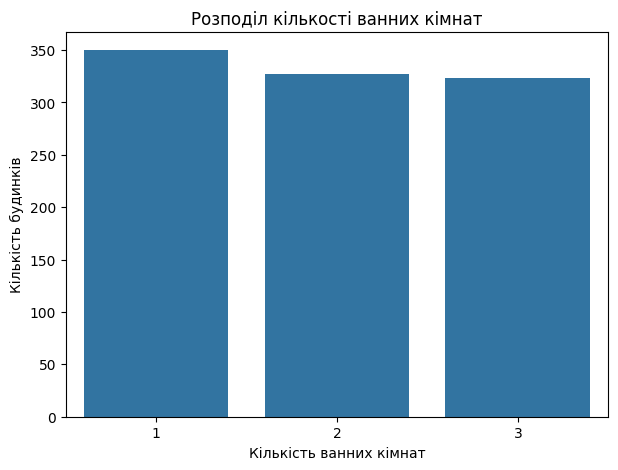

In [10]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Num_Bathrooms"
)

plt.title("Розподіл кількості ванних кімнат")
plt.xlabel("Кількість ванних кімнат")
plt.ylabel("Кількість будинків")

plt.show()




### Додаткове завдання
За потреби побудуйте попарні графіки числових ознак і коротко проаналізуйте можливі залежності.

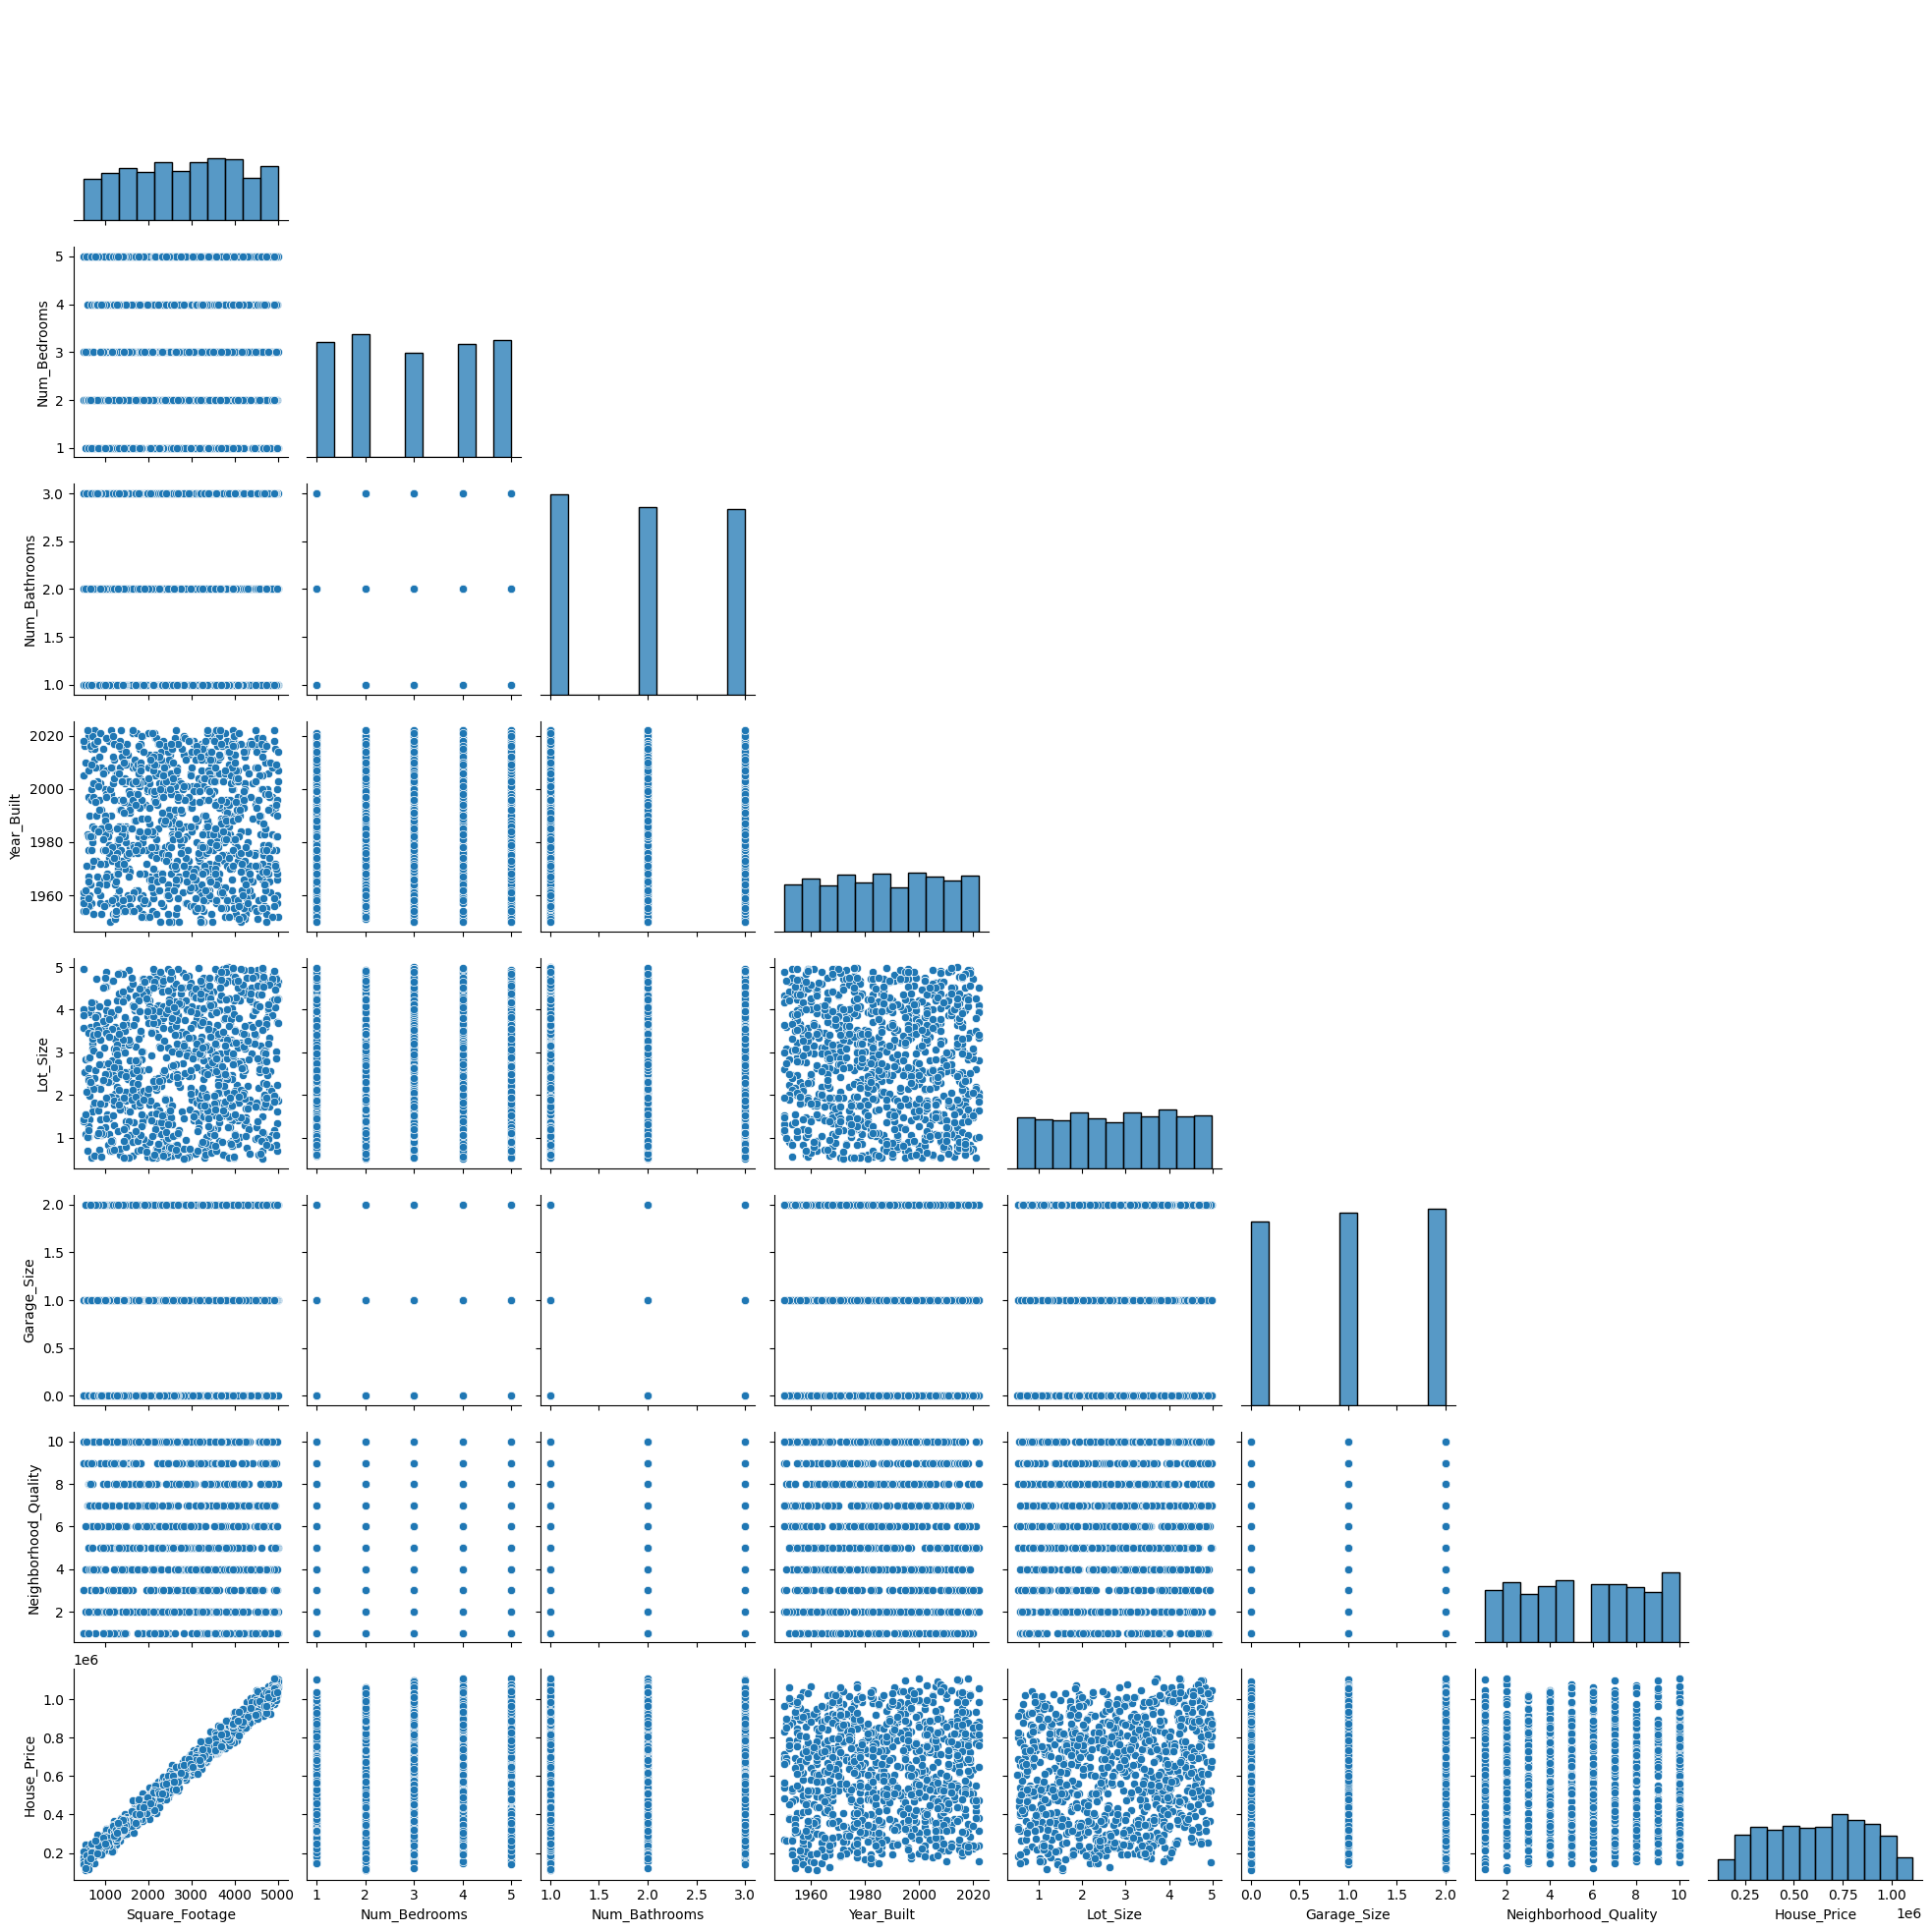

In [11]:
sns.pairplot(
    df,
    corner=True
)

plt.show()





## 6. Кореляційний аналіз

### Завдання 9. Матриця кореляції
Побудуйте кореляційну матрицю для числових ознак та відобразіть її у вигляді теплової карти.

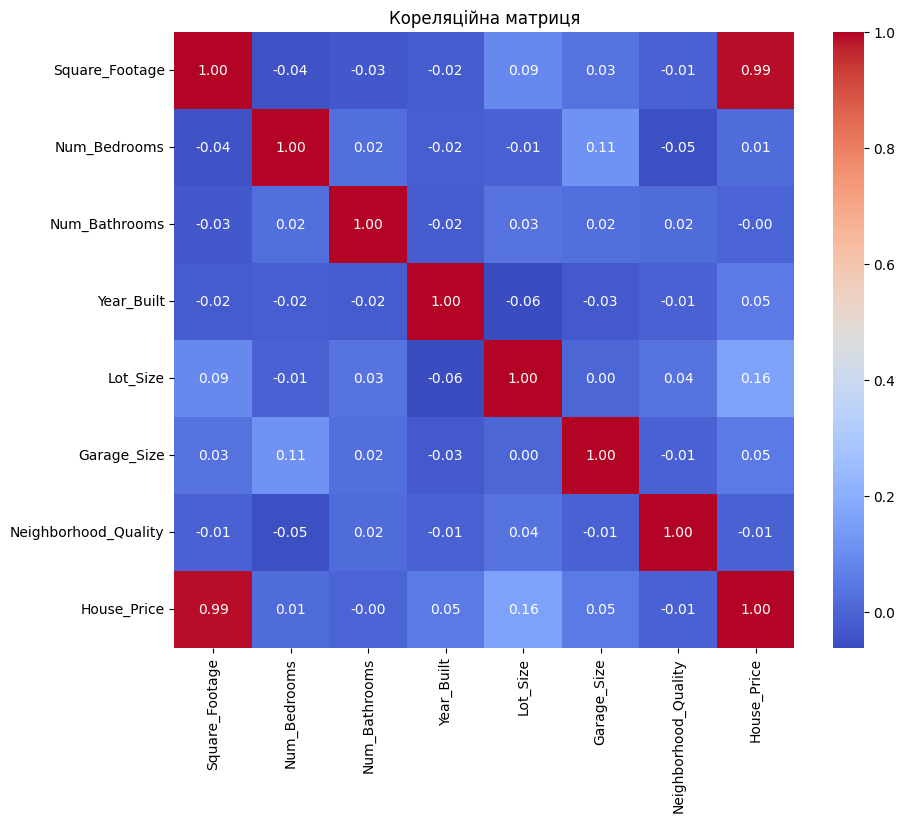

In [12]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Кореляційна матриця")
plt.show()





### Завдання 10. Кореляція з цільовою змінною
Виведіть кореляцію кожної ознаки з `House_Price`, відсортувавши значення за спаданням.

In [13]:
price_correlations = (
    df.corr(numeric_only=True)["House_Price"]
    .sort_values(ascending=False)
)

print("Кореляція ознак з House_Price:")
print(price_correlations)





Кореляція ознак з House_Price:
House_Price             1.000000
Square_Footage          0.991261
Lot_Size                0.160412
Garage_Size             0.052133
Year_Built              0.051967
Num_Bedrooms            0.014633
Num_Bathrooms          -0.001862
Neighborhood_Quality   -0.007770
Name: House_Price, dtype: float64


## 7. Побудова моделей регресії

### Завдання 11. Імпорт інструментів Scikit-learn
Імпортуйте засоби для:
- поділу вибірки;
- масштабування ознак;
- побудови Linear Regression, Ridge, Lasso, Random Forest та Gradient Boosting;
- створення Pipeline;
- обчислення R², MAE та MSE.

In [14]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)





### Завдання 12. Формування `X` і `y`
Відокремте ознаки від цільової змінної `House_Price`.

In [15]:
X = df.drop(columns=["House_Price"])
y = df["House_Price"]

print("Розмір X:", X.shape)
print("Розмір y:", y.shape)

print("\nОзнаки X:")
print(X.columns.tolist())

print("\nЦільова змінна:")
print("House_Price")





Розмір X: (1000, 7)
Розмір y: (1000,)

Ознаки X:
['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size', 'Garage_Size', 'Neighborhood_Quality']

Цільова змінна:
House_Price


### Завдання 13. Поділ даних
Поділіть дані на навчальну і тестову вибірки у співвідношенні 80/20. Для відтворюваності використайте `random_state=42`.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Розмір навчальної вибірки:", X_train.shape)
print("Розмір тестової вибірки:", X_test.shape)

print("Кількість навчальних записів:", len(X_train))
print("Кількість тестових записів:", len(X_test))





Розмір навчальної вибірки: (800, 7)
Розмір тестової вибірки: (200, 7)
Кількість навчальних записів: 800
Кількість тестових записів: 200


### Завдання 14. Створення моделей
Створіть п’ять моделей:
1. Linear Regression;
2. Ridge;
3. Lasso;
4. Random Forest Regressor;
5. Gradient Boosting Regressor.

Для лінійних моделей використайте `Pipeline` зі `StandardScaler`. Для деревоподібних моделей масштабування не потрібне.

In [17]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge())
    ]),

    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso())
    ]),

    "Random Forest": RandomForestRegressor(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

print("Створені моделі:")

for name in models:
    print(name)





Створені моделі:
Linear Regression
Ridge
Lasso
Random Forest
Gradient Boosting


### Завдання 15. Навчання та оцінювання моделей
Для кожної моделі:
- виконайте навчання на тренувальній вибірці;
- отримайте прогноз для тестової вибірки;
- обчисліть `R²`, `MAE`, `MSE`;
- збережіть результати для подальшого порівняння.

In [18]:
results = []
predictions = {}

for name, model in models.items():

    # Навчання моделі
    model.fit(X_train, y_train)

    # Прогноз
    y_pred = model.predict(X_test)

    # Збереження прогнозів
    predictions[name] = y_pred

    # Метрики
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    results.append({
        "Model": name,
        "R²": r2,
        "MAE": mae,
        "MSE": mse
    })

results_df = pd.DataFrame(results)

display(results_df)




,Model,R²,MAE,MSE
0,Linear Regression,0.998426,8174.583600,1.014348e+08
1,Ridge,0.998410,8241.586911,1.024810e+08
2,Lasso,0.998426,8174.748374,1.014366e+08
3,Random Forest,0.993886,16114.289644,3.941317e+08
4,Gradient Boosting,0.996510,12305.217615,2.249656e+08


### Завдання 16. Графічне порівняння прогнозів
Для кожної моделі побудуйте графік **фактичні значення vs прогнозовані значення**. Додайте лінію ідеального прогнозу.

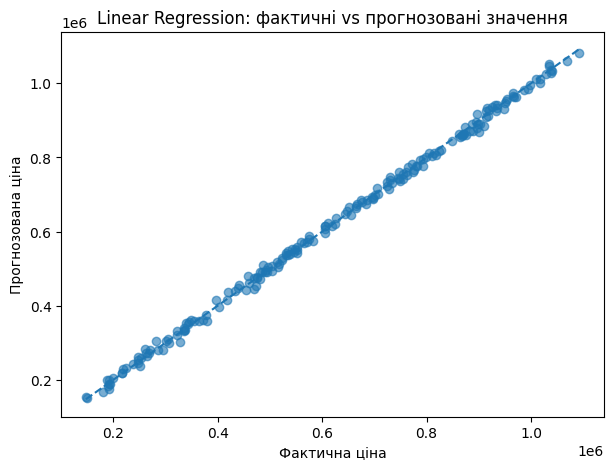

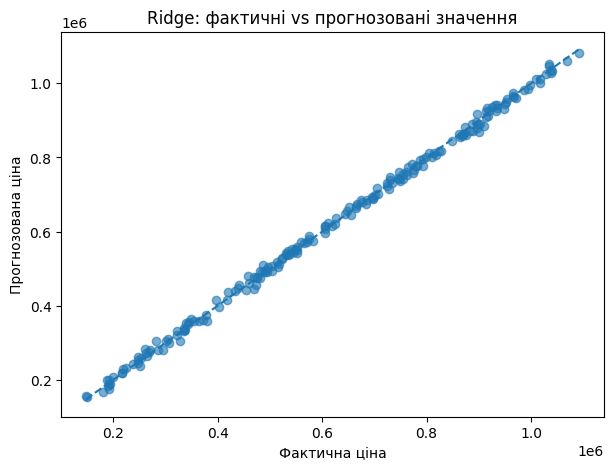

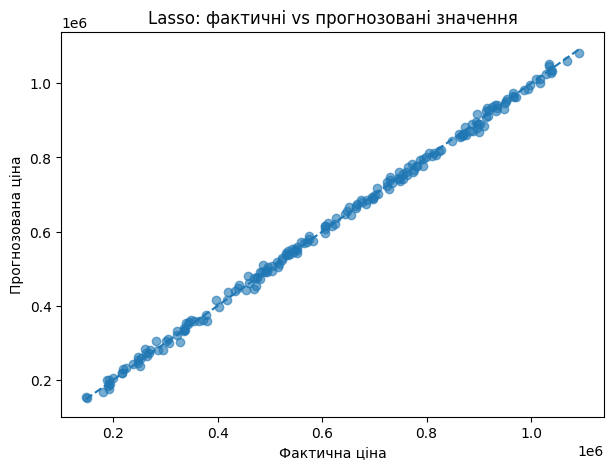

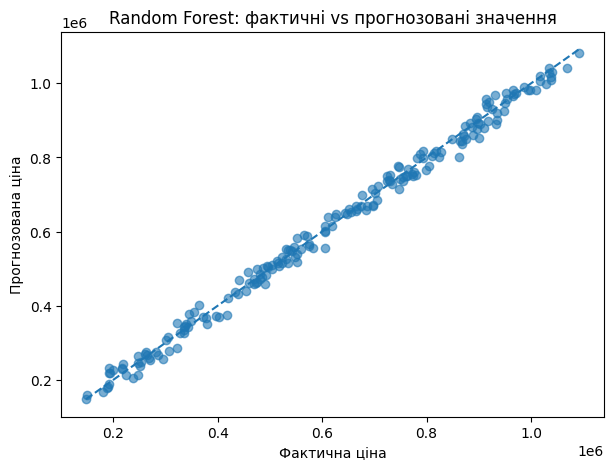

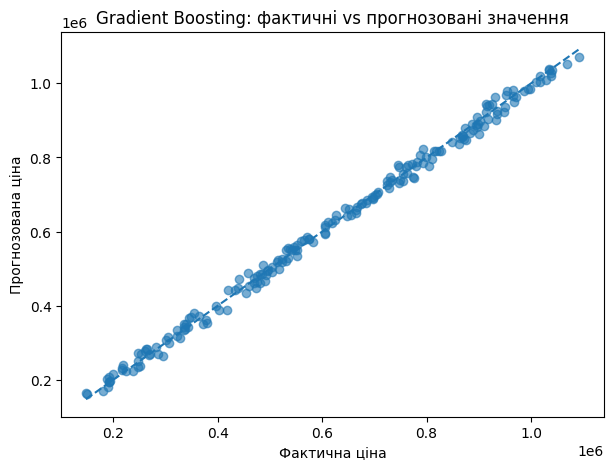

In [19]:
for name, y_pred in predictions.items():

    plt.figure(figsize=(7, 5))

    plt.scatter(
        y_test,
        y_pred,
        alpha=0.6
    )

    min_value = min(
        y_test.min(),
        y_pred.min()
    )

    max_value = max(
        y_test.max(),
        y_pred.max()
    )

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    plt.xlabel("Фактична ціна")
    plt.ylabel("Прогнозована ціна")
    plt.title(
        f"{name}: фактичні vs прогнозовані значення"
    )

    plt.show()





## 8. Підбір гіперпараметрів Random Forest

### Завдання 17. GridSearchCV
Виконайте підбір оптимальних параметрів для `RandomForestRegressor` за допомогою `GridSearchCV`.

Дослідіть щонайменше такі параметри:
- `n_estimators`;
- `max_features`;
- `max_depth`;
- `min_samples_split`.

Використайте крос-валідацію та метрику `R²`.

In [20]:
param_grid = {
    "n_estimators": [100, 200],
    "max_features": ["sqrt", "log2"],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf = RandomForestRegressor(
    random_state=42
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Найкращі параметри:")
print(grid_search.best_params_)

print("\nНайкращий результат CV R²:")
print(grid_search.best_score_)





Найкращі параметри:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}

Найкращий результат CV R²:
0.9626779849469085


### Завдання 18. Оптимізована модель Random Forest
Створіть нову модель з найкращими параметрами, навчіть її та обчисліть `R²`, `MAE`, `MSE` на тестовій вибірці.

In [21]:
best_rf = grid_search.best_estimator_

best_rf_pred = best_rf.predict(X_test)

optimized_r2 = r2_score(
    y_test,
    best_rf_pred
)

optimized_mae = mean_absolute_error(
    y_test,
    best_rf_pred
)

optimized_mse = mean_squared_error(
    y_test,
    best_rf_pred
)

print("Оптимізований Random Forest")
print(f"R²: {optimized_r2:.6f}")
print(f"MAE: {optimized_mae:.2f}")
print(f"MSE: {optimized_mse:.2f}")





Оптимізований Random Forest
R²: 0.966576
MAE: 34521.40
MSE: 2154491920.14


### Завдання 19. Порівняння Random Forest до і після оптимізації
Порівняйте значення `R²`, `MAE` і `MSE` для базової та оптимізованої моделей.

In [22]:
base_rf_pred = predictions["Random Forest"]

base_r2 = r2_score(
    y_test,
    base_rf_pred
)

base_mae = mean_absolute_error(
    y_test,
    base_rf_pred
)

base_mse = mean_squared_error(
    y_test,
    base_rf_pred
)

comparison = pd.DataFrame({
    "Метрика": [
        "R²",
        "MAE",
        "MSE"
    ],

    "До оптимізації": [
        base_r2,
        base_mae,
        base_mse
    ],

    "Після оптимізації": [
        optimized_r2,
        optimized_mae,
        optimized_mse
    ]
})

display(comparison)





,Метрика,До оптимізації,Після оптимізації
0,R²,9.938855e-01,9.665757e-01
1,MAE,1.611429e+04,3.452140e+04
2,MSE,3.941317e+08,2.154492e+09


### Завдання 20. Аналіз оптимізації
Зробіть короткий висновок:
- чи покращилася якість моделі після підбору параметрів;
- які метрики змінилися;
- чи доцільно використовувати оптимізовану модель.

**Ваш висновок:**

Після підбору гіперпараметрів за допомогою GridSearchCV якість Random Forest на тестовій вибірці не покращилася. Базова модель отримала R² = 0.993886, MAE = 16114.29 та MSE = 394131747.45. Після оптимізації результати становили R² = 0.966576, MAE = 34521.40 та MSE = 2154491920.14. Таким чином, на використаній тестовій вибірці базова модель Random Forest показала кращий результат. GridSearchCV підбирав параметри за 5-кратною крос-валідацією навчальної вибірки, тому найкращий результат крос-валідації не гарантує покращення на окремій тестовій вибірці.

## 9. Аналіз прогнозів лінійної регресії

### Завдання 21. Таблиця прогнозів
Для моделі Linear Regression створіть таблицю з трьома стовпцями:
- фактична ціна;
- прогнозована ціна;
- похибка у відсотках.

Виведіть 10 випадкових рядків.

In [23]:
linear_predictions = predictions["Linear Regression"]

prediction_table = pd.DataFrame({
    "Фактична ціна": y_test.values,
    "Прогнозована ціна": linear_predictions
})

prediction_table["Похибка (%)"] = (
    abs(
        prediction_table["Фактична ціна"]
        - prediction_table["Прогнозована ціна"]
    )
    / prediction_table["Фактична ціна"]
) * 100

print("10 випадкових прогнозів:")

display(
    prediction_table
    .sample(10, random_state=42)
    .round(2)
)





10 випадкових прогнозів:


,Фактична ціна,Прогнозована ціна,Похибка (%)
95,1068538.11,1059729.02,0.82
15,194353.74,187868.55,3.34
30,270230.64,279715.82,3.51
158,986006.86,981949.27,0.41
128,953339.73,957382.95,0.42
115,914555.75,909764.27,0.52
69,746167.73,742469.14,0.50
170,646766.29,654445.55,1.19
174,523323.07,524605.44,0.25
45,1008539.16,1011343.64,0.28


## 10. Висновки
Сформулюйте загальний висновок за результатами лабораторної роботи. Вкажіть:

1. Які моделі було побудовано.
2. Яка модель показала найкращі значення метрик.
3. Як вплинув підбір гіперпараметрів Random Forest.
4. Наскільки точними є прогнози на тестовій вибірці.
5. Які фактори можуть впливати на якість прогнозування ціни нерухомості.

**Загальний висновок:**

У ході лабораторної роботи було проведено первинний аналіз набору даних про нерухомість, який містить 1000 записів та 8 числових ознак. Було перевірено структуру даних, наявність дублікатів і пропущених значень. Дублікатів та пропущених значень у датасеті не виявлено.

Було проаналізовано окремі ознаки Neighborhood_Quality та Num_Bathrooms, а також побудовано графіки їх розподілу. Додатково було побудовано попарні графіки числових ознак і кореляційну матрицю.

Кореляційний аналіз показав, що найбільш сильний зв'язок із ціною будинку має Square_Footage. Коефіцієнт кореляції між площею будинку та House_Price становить 0.991261, що свідчить про дуже сильний позитивний зв'язок.

Для прогнозування вартості нерухомості було побудовано п'ять моделей: Linear Regression, Ridge, Lasso, Random Forest та Gradient Boosting. Найкращий результат на тестовій вибірці показала Linear Regression: R² = 0.998426, MAE = 8174.58 та MSE = 101434798.51.

Також було виконано підбір гіперпараметрів Random Forest за допомогою GridSearchCV. Найкращими параметрами за результатами крос-валідації стали n_estimators = 200, max_features = sqrt, max_depth = 20 та min_samples_split = 2. Однак після оптимізації результат Random Forest на тестовій вибірці погіршився: R² зменшився з 0.993886 до 0.966576, а MAE та MSE збільшилися.

Аналіз прогнозів Linear Regression показав, що прогнозовані значення близькі до фактичних. Отримані результати демонструють, що для цього набору даних лінійна регресія добре описує залежність між характеристиками будинку та його вартістю. Найбільший вплив на прогноз ціни має площа будинку, а якість прогнозування також залежить від інших характеристик нерухомості, обсягу та якості навчальних даних.